# 3 — Complete workflow: from a CTD file to lake indicators

This notebook combines reading, quality control, visualization, and profile analysis. It is intentionally shorter than the two teaching notebooks: use it as a reusable template after understanding the individual steps.

## Workflow

1. create or select a CTD file;
2. read it with the public interface;
3. identify depth and temperature;
4. clean the cast;
5. inspect the profile;
6. estimate thermocline and centre of buoyancy;
7. report results together with assumptions.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pylake

repository_root = Path.cwd()
if not (repository_root / "examples").is_dir():
    repository_root = repository_root.parent
if not (repository_root / "examples").is_dir():
    raise FileNotFoundError("Run this notebook from the PyLake repository or its notebooks directory.")
sys.path.insert(0, str(repository_root))

from examples.generate_ctd_examples import main as generate_examples
from pylake import functions as fn

## Step 1 — Select a reproducible file

We use the Sea & Sun example because it contains recognizable pressure and temperature variables. Replace the path later with a real `.tob`, `.rsk`, KOR CSV, or DataLakes export.

In [2]:
data_directory = generate_examples()
path = data_directory / "example.tob"
path

PosixPath('/Users/wahboulet/Projects/PyLake/examples/data/example.tob')

## Step 2 — Read and inspect

Never assume variable names before inspecting the Dataset. Different formats use different channel names.

In [3]:
dataset = pylake.read(path)
dataset

<xarray.Dataset> Size: 1kB
Dimensions:            (time: 20)
Coordinates:
  * time               (time) datetime64[us] 160B 2026-01-01 ... 2026-01-01T0...
Data variables:
    pressure           (time) float64 160B 0.0 1.0 2.0 3.0 ... 17.0 18.0 19.0
    temperature        (time) float64 160B 21.0 20.75 20.49 ... 11.75 11.5 11.25
    conductivity       (time) float64 160B 0.4 0.4 0.4 0.4 ... 0.4 0.4 0.4 0.4
    chlorophyll        (time) float64 160B 0.1 0.1 0.1 0.1 ... 0.1 0.1 0.1 0.1
    turbidity          (time) float64 160B 0.2 0.2 0.2 0.2 ... 0.2 0.2 0.2 0.2
    pH                 (time) float64 160B 7.2 7.2 7.2 7.2 ... 7.2 7.2 7.2 7.2
    oxygen_saturation  (time) float64 160B 98.0 98.0 98.0 ... 98.0 98.0 98.0
    oxygen_mg_l        (time) float64 160B 9.0 9.0 9.0 9.0 ... 9.0 9.0 9.0 9.0
Attributes:
    source:   Sea & Sun

In [4]:
pd.DataFrame({
    "variable": list(dataset.data_vars),
    "dimensions": [str(dataset[name].dims) for name in dataset.data_vars],
    "units": [dataset[name].attrs.get("units", "not provided") for name in dataset.data_vars],
})

,variable,dimensions,units
0,pressure,"('time',)",not provided
1,temperature,"('time',)",not provided
2,conductivity,"('time',)",not provided
3,chlorophyll,"('time',)",not provided
4,turbidity,"('time',)",not provided
5,pH,"('time',)",not provided
6,oxygen_saturation,"('time',)",not provided
7,oxygen_mg_l,"('time',)",not provided


## Step 3 — Extract the scientific variables

For this example, pressure is used as a depth proxy. For precise field analysis, convert pressure to depth when required by the instrument protocol and document the conversion.

In [5]:
raw_depth = np.asarray(dataset["pressure"], dtype=float)
raw_temperature = np.asarray(dataset["temperature"], dtype=float)

raw = pd.DataFrame({
    "depth_or_pressure": raw_depth,
    "temperature_c": raw_temperature,
})
raw.head()

,depth_or_pressure,temperature_c
0,0.0,20.998
1,1.0,20.745
2,2.0,20.488
3,3.0,20.217
4,4.0,19.910


## Step 4 — Quality control

The downcast indices are applied to both variables. Repeated depths are then averaged. Keeping these two operations explicit makes the cleaning decisions auditable.

In [6]:
kept_rows = fn.depth_filter(raw_depth, run_length=3, index=True)
downcast_depth = raw_depth[kept_rows]
downcast_temperature = raw_temperature[kept_rows]

clean_depth, clean_temperature = fn.depth_average(
    downcast_depth,
    downcast_temperature,
)

clean = pd.DataFrame({
    "depth_or_pressure": clean_depth,
    "temperature_c": clean_temperature,
})
clean.head()

,depth_or_pressure,temperature_c
0,0.0,20.998
1,1.0,20.745
2,2.0,20.488
3,3.0,20.217
4,4.0,19.910


In [7]:
quality_control = pd.Series({
    "source": dataset.attrs.get("source"),
    "raw_measurements": raw_depth.size,
    "retained_downcast_measurements": downcast_depth.size,
    "unique_clean_depths": clean_depth.size,
    "missing_temperatures": int(np.isnan(raw_temperature).sum()),
})
quality_control

source                            Sea & Sun
raw_measurements                         20
retained_downcast_measurements           20
unique_clean_depths                      20
missing_temperatures                      0
dtype: object

## Step 5 — Plot before calculating

A plot can reveal inverted axes, impossible values, gaps, spikes, or a profile that is actually mixed.

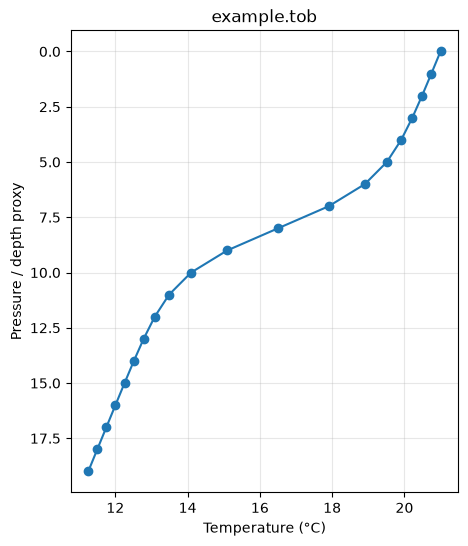

In [8]:
fig, ax = plt.subplots(figsize=(5, 6))
ax.plot(clean_temperature, clean_depth, marker="o")
ax.invert_yaxis()
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Pressure / depth proxy")
ax.set_title(path.name)
ax.grid(alpha=0.3)
plt.show()

## Step 6 — Calculate indicators

The thermocline identifies the strongest density transition. The centre of buoyancy summarizes where stratification is concentrated.

In [9]:
thermocline_depth, thermocline_index = pylake.thermocline(
    clean_temperature,
    clean_depth,
    weighted=True,
)
buoyancy_center = fn.center_buoyancy(clean_temperature, clean_depth)

results = pd.Series({
    "thermocline_depth": float(thermocline_depth),
    "thermocline_interval_index": int(thermocline_index),
    "center_buoyancy_depth": float(buoyancy_center),
})
results

thermocline_depth             7.722547
thermocline_interval_index    8.000000
center_buoyancy_depth         7.949646
dtype: float64

## A compact result table

The final output should be easy to inspect, export, and compare across profiles. A result should travel together with basic quality-control counts rather than as an isolated number.

In [10]:
report = pd.DataFrame([{
    "file": path.name,
    "source": dataset.attrs.get("source"),
    "raw_measurements": raw_depth.size,
    "clean_measurements": clean_depth.size,
    "thermocline_depth": float(thermocline_depth),
    "center_buoyancy_depth": float(buoyancy_center),
    "weighted_thermocline": True,
}])
report

,file,source,raw_measurements,clean_measurements,thermocline_depth,center_buoyancy_depth,weighted_thermocline
0,example.tob,Sea & Sun,20,20,7.722547,7.949646,True


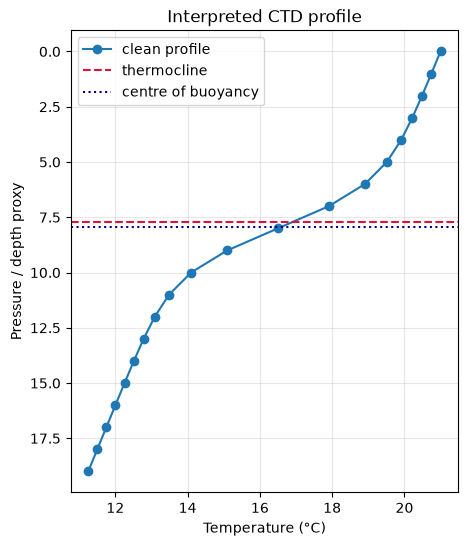

In [11]:
fig, ax = plt.subplots(figsize=(5, 6))
ax.plot(clean_temperature, clean_depth, marker="o", label="clean profile")
ax.axhline(float(thermocline_depth), color="crimson", linestyle="--", label="thermocline")
ax.axhline(float(buoyancy_center), color="navy", linestyle=":", label="centre of buoyancy")
ax.invert_yaxis()
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Pressure / depth proxy")
ax.set_title("Interpreted CTD profile")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Step 7 — Interpret and report

For this synthetic profile, warm surface water overlies colder deep water. The thermocline marks the strongest transition. The centre of buoyancy describes the overall centre of stable stratification and therefore need not equal the thermocline.

A real report should state:

- file and instrument source;
- date and location;
- depth or pressure units;
- temperature units;
- cleaning parameters;
- salinity assumption;
- whether weighted thermocline refinement was used;
- any missing values or rejected measurements.

## Reusable function

The following small function packages the demonstrated workflow. It deliberately requires explicit variable names because real instruments do not all use the same channel labels.

In [12]:
def analyse_profile(path, depth_variable, temperature_variable, run_length=3):
    dataset = pylake.read(path)
    raw_depth = np.asarray(dataset[depth_variable], dtype=float)
    raw_temperature = np.asarray(dataset[temperature_variable], dtype=float)

    kept = fn.depth_filter(raw_depth, run_length=run_length, index=True)
    depth, temperature = fn.depth_average(raw_depth[kept], raw_temperature[kept])
    thermo_depth, thermo_index = pylake.thermocline(temperature, depth)

    return {
        "dataset": dataset,
        "depth": depth,
        "temperature": temperature,
        "thermocline_depth": float(thermo_depth),
        "thermocline_index": int(thermo_index),
        "center_buoyancy": float(fn.center_buoyancy(temperature, depth)),
    }

analysis = analyse_profile(path, "pressure", "temperature")
{key: value for key, value in analysis.items() if key not in {"dataset", "depth", "temperature"}}

{'thermocline_depth': 7.722547273535059,
 'thermocline_index': 8,
 'center_buoyancy': 7.9496457843277}

## Try another format

For the RBR example, the corresponding variables are `pres24` and `temp14`.

In [13]:
rsk_analysis = analyse_profile(
    data_directory / "example.rsk",
    depth_variable="pres24",
    temperature_variable="temp14",
)

{key: value for key, value in rsk_analysis.items() if key not in {"dataset", "depth", "temperature"}}

{'thermocline_depth': 7.722843593171335,
 'thermocline_index': 8,
 'center_buoyancy': 7.949208865367085}

## Final checklist

Before trusting a result, confirm:

- [ ] the correct file and source were detected;
- [ ] depth increases in the intended direction;
- [ ] units are known;
- [ ] temperature values are plausible;
- [ ] the retained downcast was inspected;
- [ ] repeated depths were handled;
- [ ] the thermocline is visible on the plot;
- [ ] assumptions are recorded.

The code produces numbers; the plot, metadata, and documented assumptions make those numbers scientifically interpretable.